# Exploring Satellite Passes - Monotonic Concave Cal Edition

In [45]:
import os
from pathlib import Path

import h5py
import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC

from embers_passes import PassFile

import mwa_hyperbeam
# wget http://ws.mwatelescope.org/static/mwa_full_embedded_element_pattern.h5
os.environ["MWA_BEAM_FILE"] = "../../hyperbeam/mwa_full_embedded_element_pattern.h5"
beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

In [2]:
def make_unpol_instrumental_response(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """
    Convert Jones matrices to unpolarized instrumental beam responses.

    Parameters
    ----------
    j1, j2 : np.ndarray
        Arrays of Jones terms with shape (N, 4), where the Jones matrix is
        flattened as [j00, j01, j10, j11].

    Returns
    -------
    np.ndarray
        Array of shape (N, 4) containing [XX, XY, YX, YY] instrumental
        responses for an unpolarized source.
    """
    result = np.empty_like(j1)

    result[:, 0] = j1[:, 0] * j2[:, 0].conjugate() + j1[:, 1] * j2[:, 1].conjugate()
    result[:, 1] = j1[:, 0] * j2[:, 2].conjugate() + j1[:, 1] * j2[:, 3].conjugate()
    result[:, 2] = j1[:, 2] * j2[:, 0].conjugate() + j1[:, 3] * j2[:, 1].conjugate()
    result[:, 3] = j1[:, 2] * j2[:, 2].conjugate() + j1[:, 3] * j2[:, 3].conjugate()

    return result

In [30]:
beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

## Binning to healpix

In [44]:
def pass_hyperbeam_model(
    p,
    beam,
    freq_hz: float = 137e6,
    delays: list[int] | None = None,
    amps: list[float] | None = None,
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """
    Evaluate the MWA hyperbeam model along a single pass.

    Parameters
    ----------
    p : PassRecord
        Pass record with alt_deg and az_deg arrays.
    beam : mwa_hyperbeam.FEEBeam
        Hyperbeam beam object.
    freq_hz : float, optional
        Frequency in Hz.
    delays : list[int], optional
        Beamformer delays.
    amps : list[float], optional
        Dipole amplitudes.
    norm_to_zenith : bool, optional
        Whether to normalize to zenith.
    parallactic : bool, optional
        Whether to include parallactic rotation.

    Returns
    -------
    np.ndarray
        Beam model in dB sampled at the pass coordinates.
    """
    if delays is None:
        delays = [0] * 16
    if amps is None:
        amps = [1.0] * 16

    az = np.radians(np.asarray(p.az_deg, dtype=float))
    za = np.radians(90.0 - np.asarray(p.alt_deg, dtype=float))

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    pol = p.tile[-2:]  # "XX" or "YY"

    if pol == "XX":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 0]))
    elif pol == "YY":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 3]))
    else:
        raise ValueError(f"Could not infer polarization from tile name: {p.tile}")

    return model

In [350]:
def passes_to_healpix(
    passes,
    mwa_model_threshold_db: float = -10,
    residual_thresh: float = 2,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Bin pass samples onto a healpix map.

    Parameters
    ----------
    passes : iterable of PassRecord
        Iterable of pass records. Each record must have `alt_deg`, `az_deg`,
        and `power_db` attributes.
    nside : int, optional
        Healpix nside. Default is 32.

    Returns
    -------
    hp_map : np.ndarray
        Healpix map of binned power values. Pixels with no samples are NaN.
    counts : np.ndarray
        Number of samples contributing to each pixel.
    """
    npix = hp.nside2npix(nside)

    pow_values: list[list[float]] = [[] for _ in range(npix)]
    cal_values: list[list[float]] = [[] for _ in range(npix)]

    flagged_passes = 0
    flagged_counts = 0

    for p in passes:
        alt_deg = np.asarray(p.alt_deg, dtype=float)
        az_deg = np.asarray(p.az_deg, dtype=float)
        pow_db = np.asarray(p.power_db, dtype=float)
        cal_db = np.asarray(p.cal_db, dtype=float)
        mwa_db = pass_hyperbeam_model(p, beam)
        res_db = pow_db - mwa_db

        # Non zero cal applied
        if cal_db.max() > 0:
            # Find area of MWA beam where correction likely to have been applied
            mwa_high_mask = np.where(mwa_db > mwa_model_threshold_db)[0]

            # Find peak correction in this 
            if mwa_high_mask.size > 0:
                # if the measurement is above 2dB over mwa beam expectation
                if res_db[mwa_high_mask].max() > residual_thresh:
                    flagged_passes +=1
                    flagged_counts += pow_db.size
                    
                else:
                    theta = np.radians(90.0 - alt_deg)
                    phi = np.radians(az_deg)
            
                    pix = hp.ang2pix(nside, theta, phi)
            
                    for i, p in enumerate(pix):
                        pow_values[p].append(float(pow_db[i]))
                        cal_values[p].append(float(cal_db[i]))

            else:
                theta = np.radians(90.0 - alt_deg)
                phi = np.radians(az_deg)
        
                pix = hp.ang2pix(nside, theta, phi)
        
                for i, p in enumerate(pix):
                    pow_values[p].append(float(pow_db[i]))
                    cal_values[p].append(float(cal_db[i]))

        # No calibration applied to this pass
        else:
            theta = np.radians(90.0 - alt_deg)
            phi = np.radians(az_deg)
    
            pix = hp.ang2pix(nside, theta, phi)
    
            for i, p in enumerate(pix):
                pow_values[p].append(float(pow_db[i]))
                cal_values[p].append(float(cal_db[i]))

    pow_hpx = np.full(npix, np.nan, dtype=float)
    cal_hpx = np.full(npix, np.nan, dtype=float)
    count_hpx = np.zeros(npix, dtype=int)

    for pixel, pv in enumerate(pow_values):
        count_hpx[pixel] = len(pv)
        if pv:
            pow_hpx[pixel] = np.median(pv)
            cal_hpx[pixel] = np.median(cal_values[pixel])

    print(f"Flagged Passes: [ {100*flagged_passes / len(passes):.2f}%: ({flagged_passes}/{len(passes)}) ]")
    print(f"Flagged Data Percent: [ {100*flagged_counts/(flagged_counts+count_hpx.sum()):.2f}% ]")
            
    return pow_hpx, cal_hpx, count_hpx

In [357]:
def passes_to_healpix(
    passes,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Bin satellite-pass power samples onto a HEALPix map.

    Samples from all passes are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The output power map contains the median
    of all finite power samples contributing to each pixel.

    This function is intended for older pass data that do not contain an RFE
    calibration correction field. No calibration-based thresholding or MWA
    beam-model comparison is applied.

    Parameters
    ----------
    passes : sequence of PassRecord
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, and ``power_db``.
    nside : int, optional
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map : np.ndarray
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    count_map : np.ndarray
        Number of finite samples contributing to each HEALPix pixel.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape == az_deg.shape == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        finite = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
        )

        if not np.any(finite):
            continue

        theta = np.radians(90.0 - alt_deg[finite])
        phi = np.radians(az_deg[finite])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(pixels, power_db[finite]):
            power_values[pixel].append(float(power))

    power_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)

    return power_map, count_map

In [355]:
def passes_to_healpix_concave_monotonic(
    passes,
    mwa_model_threshold_db: float = -10.0,
    residual_thresh: float = 2.0,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Bin calibrated satellite-pass samples onto HEALPix maps.

    Samples from each accepted pass are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The final power and calibration maps
    contain the median of all samples contributing to each pixel.

    Passes with a non-zero RFE calibration are compared against the MWA beam
    model. A pass is rejected when its measured power exceeds the model by
    more than ``residual_thresh`` within the region where the model response is
    above ``mwa_model_threshold_db``.

    Parameters
    ----------
    passes : sequence of PassRecord
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, ``power_db``, and ``cal_db``. The records
        must also be compatible with :func:`pass_hyperbeam_model`.
    mwa_model_threshold_db : float, optional
        Minimum MWA model response used when testing calibrated passes, in dB
        relative to the beam maximum. Default is -10 dB.
    residual_thresh : float, optional
        Maximum permitted positive residual between the measured pass and MWA
        beam model within the selected model region, in dB. Default is 2 dB.
    nside : int, optional
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map : np.ndarray
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    calibration_map : np.ndarray
        Median RFE calibration correction in each HEALPix pixel. Pixels
        containing no samples are set to NaN.
    count_map : np.ndarray
        Number of individual samples contributing to each HEALPix pixel.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]
    calibration_values: list[list[float]] = [[] for _ in range(npix)]

    flagged_passes = 0
    flagged_samples = 0

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)
        calibration_db = np.asarray(pass_record.cal_db, dtype=float)

        mwa_model_db = np.asarray(
            pass_hyperbeam_model(pass_record, beam),
            dtype=float,
        )
        residual_db = power_db - mwa_model_db

        calibration_applied = np.max(calibration_db) > 0.0
        reject_pass = False

        if calibration_applied:
            model_region = mwa_model_db > mwa_model_threshold_db

            if np.any(model_region):
                peak_residual_db = np.max(residual_db[model_region])
                reject_pass = peak_residual_db > residual_thresh

        if reject_pass:
            flagged_passes += 1
            flagged_samples += power_db.size
            continue

        theta = np.radians(90.0 - alt_deg)
        phi = np.radians(az_deg)
        pixels = hp.ang2pix(nside, theta, phi)

        for pixel, power, correction in zip(
            pixels,
            power_db,
            calibration_db,
        ):
            power_values[pixel].append(float(power))
            calibration_values[pixel].append(float(correction))

    power_map = np.full(npix, np.nan, dtype=float)
    calibration_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)
            calibration_map[pixel] = np.median(
                calibration_values[pixel]
            )

    n_passes = len(passes)
    accepted_samples = int(count_map.sum())
    total_samples = accepted_samples + flagged_samples

    flagged_pass_fraction = (
        100.0 * flagged_passes / n_passes
        if n_passes > 0
        else 0.0
    )
    flagged_sample_fraction = (
        100.0 * flagged_samples / total_samples
        if total_samples > 0
        else 0.0
    )

    print(
        "Flagged passes: "
        f"{flagged_pass_fraction:.2f}% "
        f"({flagged_passes}/{n_passes} passes)"
    )
    print(
        "Flagged data: "
        f"{flagged_sample_fraction:.2f}% "
        f"({flagged_samples}/{total_samples} samples)"
    )

    return power_map, calibration_map, count_map

Flagged passes: 3.42% (65/1900 passes)
Flagged data: 4.37% (43724/1000748 samples)


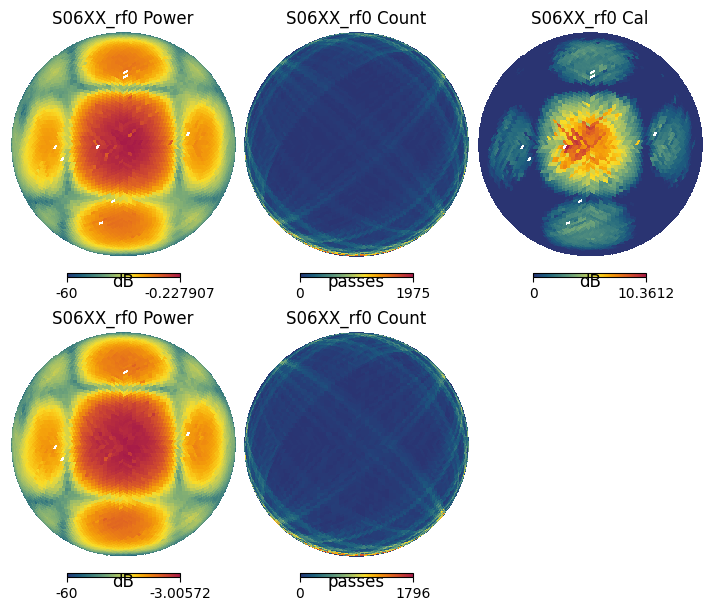

In [365]:
%matplotlib inline

pf_mc = PassFile("../passes/monotonic_concave_cal/rf0/S06XX_rf0XX_passes.h5")
passes_mc = pf_mc.read_passes(pointing=0)

pf_orig = PassFile("../passes/rf0/S06XX_rf0XX_passes.h5")
passes_orig = pf_orig.read_passes(pointing=0)

pow_hpx_orig, count_hpx_orig = passes_to_healpix(passes_orig, nside=32)
pow_hpx_mc, cal_hpx_mc, count_hpx_mc = passes_to_healpix_concave_monotonic(passes_mc, nside=32)

fig = plt.figure(figsize=(7, 6))

hp.orthview(pow_hpx_mc, fig=fig, sub=(2, 3, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc, fig=fig, sub=(2, 3, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd)
hp.orthview(cal_hpx_mc, fig=fig, sub=(2, 3, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Cal", unit="dB", cmap=prd)

hp.orthview(pow_hpx_orig, fig=fig, sub=(2, 3, 4), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_orig, fig=fig, sub=(2, 3, 5), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd)